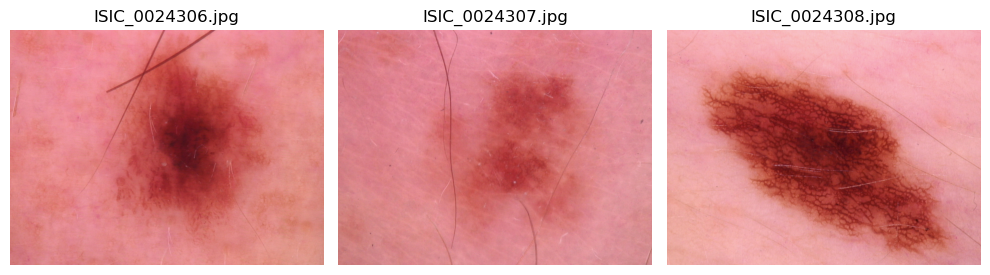

(450, 600, 3)

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

image_dir = "../Data/HAM10000/HAM10000_images_part_1"

image_files = sorted(os.listdir(image_dir))

# Take the first 3
subset_files = image_files[:3]
images = [Image.open(os.path.join(image_dir, f)) for f in subset_files]

plt.figure(figsize=(10, 4))

for i, img in enumerate(images):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(subset_files[i])

plt.tight_layout()
plt.show()

image_arrays = [np.array(img) for img in images]

image_arrays[0].shape


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm

sns.set(style="whitegrid")

PROJECT_ROOT = Path("..")
DATA_PATH = PROJECT_ROOT / "Data" / "HAM10000_data"

METADATA_PATH = DATA_PATH / "HAM10000_metadata.csv"
IMG_PATH_1 = DATA_PATH / "HAM10000_images_part_1"
IMG_PATH_2 = DATA_PATH / "HAM10000_images_part_2"

print("Metadata path:", METADATA_PATH)

Metadata path: ../Data/HAM10000_data/HAM10000_metadata.csv


In [ ]:
df = pd.read_csv(METADATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
print("Unique lesions:", df["lesion_id"].nunique())
print("Unique images:", df["image_id"].nunique())
print("Classes:", df["dx"].unique())

df.info()

Unique lesions: 7470
Unique images: 10015
Classes: ['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


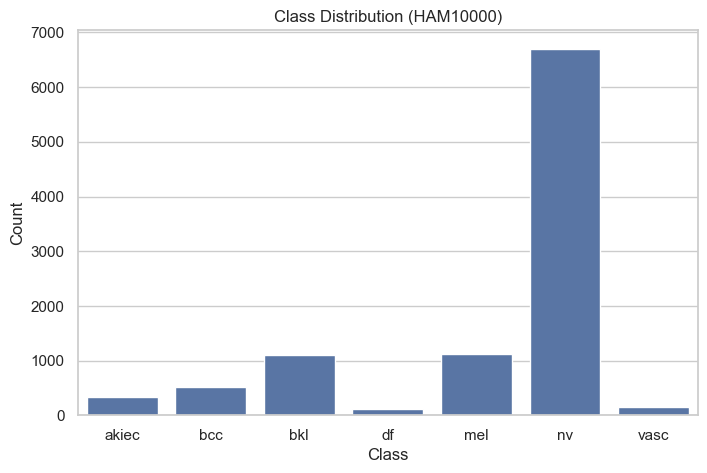

       Count  Percent
dx                   
akiec    327     3.27
bcc      514     5.13
bkl     1099    10.97
df       115     1.15
mel     1113    11.11
nv      6705    66.95
vasc     142     1.42


In [ ]:
# Class distribution

class_counts = df["dx"].value_counts().sort_index()
class_percent = 100 * class_counts / len(df)

plt.figure(figsize=(8,5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Distribution (HAM10000)")
plt.ylabel("Count")
plt.xlabel("Class")
plt.show()

print(pd.DataFrame({
    "Count": class_counts,
    "Percent": class_percent.round(2)
}))

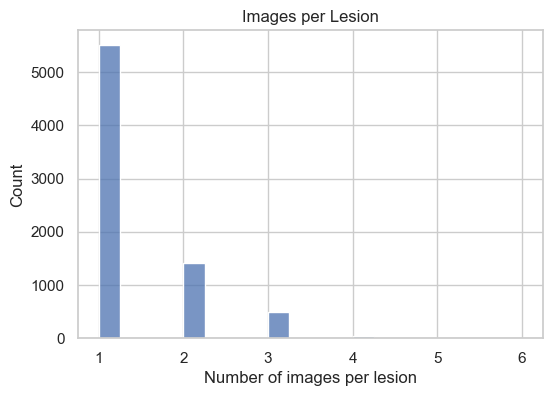

Max images per lesion: 6


In [ ]:
# Images per lesion

lesion_image_counts = df.groupby("lesion_id")["image_id"].count()

plt.figure(figsize=(6,4))
sns.histplot(lesion_image_counts, bins=20)
plt.title("Images per Lesion")
plt.xlabel("Number of images per lesion")
plt.show()

print("Max images per lesion:", lesion_image_counts.max())

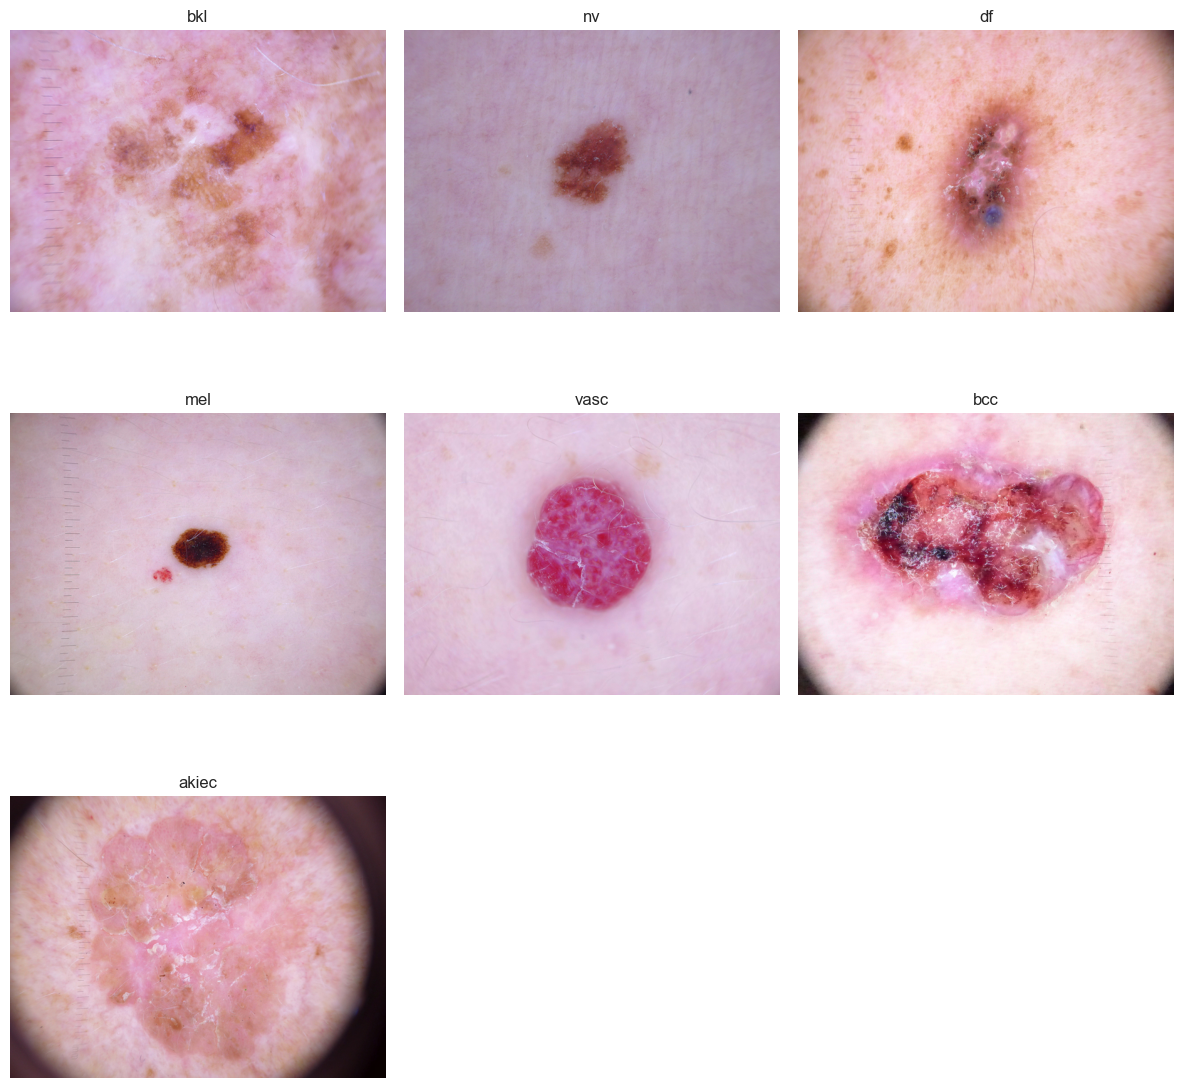

In [ ]:
# Show examples per class

def get_image_path(image_id):
    path1 = IMG_PATH_1 / f"{image_id}.jpg"
    path2 = IMG_PATH_2 / f"{image_id}.jpg"
    return path1 if path1.exists() else path2

classes = df["dx"].unique()

plt.figure(figsize=(12, 12))

for i, cls in enumerate(classes):
    sample = df[df["dx"] == cls].iloc[0]
    img_path = get_image_path(sample["image_id"])
    img = Image.open(img_path)

    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Image resolution check

sample_paths = df["image_id"].sample(200, random_state=42)

sizes = []

for img_id in tqdm(sample_paths):
    img_path = get_image_path(img_id)
    img = Image.open(img_path)
    sizes.append(img.size)

sizes = np.array(sizes)

print("Width mean:", sizes[:,0].mean())
print("Height mean:", sizes[:,1].mean())

100%|██████████| 200/200 [02:46<00:00,  1.20it/s]

Width mean: 600.0
Height mean: 450.0


In [ ]:
# Check if a lesion_id has multiple classes

lesion_class_counts = df.groupby("lesion_id")["dx"].nunique()

multi_class_lesions = lesion_class_counts[lesion_class_counts > 1]

print("Number of lesions with multiple class labels:", len(multi_class_lesions))

Number of lesions with multiple class labels: 0


In [ ]:
# Image-level distribution (original)
image_level_counts = df["dx"].value_counts().sort_index()

# Lesion-level distribution
lesion_level_df = df.drop_duplicates(subset="lesion_id")
lesion_level_counts = lesion_level_df["dx"].value_counts().sort_index()

comparison_df = pd.DataFrame({
    "Image-level count": image_level_counts,
    "Lesion-level count": lesion_level_counts
}).fillna(0)

comparison_df["Images per lesion (avg)"] = (
    comparison_df["Image-level count"] /
    comparison_df["Lesion-level count"]
)

comparison_df

,Image-level count,Lesion-level count,Images per lesion (avg)
dx,,,
akiec,327,228,1.434211
bcc,514,327,1.571865
bkl,1099,727,1.511692
df,115,73,1.575342
mel,1113,614,1.812704
nv,6705,5403,1.240977
vasc,142,98,1.448980


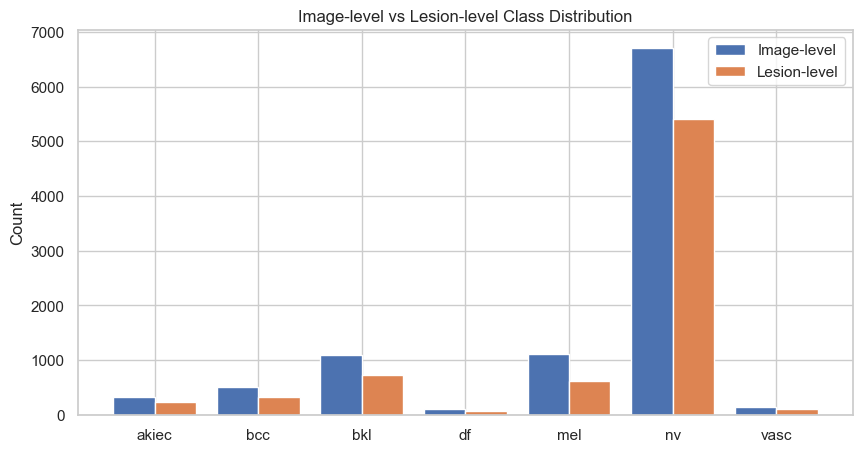

In [10]:
plt.figure(figsize=(10,5))

x = np.arange(len(image_level_counts.index))

plt.bar(x - 0.2, image_level_counts.values, width=0.4, label="Image-level")
plt.bar(x + 0.2, lesion_level_counts.values, width=0.4, label="Lesion-level")

plt.xticks(x, image_level_counts.index)
plt.ylabel("Count")
plt.title("Image-level vs Lesion-level Class Distribution")
plt.legend()
plt.show()